# Computer Exercise 4.3 — Problem 1

> **교재**: Cheney & Kincaid, *Numerical Mathematics and Computing* (7th ed.)
> **단원**: 4.3 Estimating Derivatives and Richardson Extrapolation — *Forward vs Central Differences*
> **풀이 일자**: Day 16
> **언어**: Python 3 (NumPy / Pandas / Matplotlib)

## 1. 문제 (원문)

> **1.** Numerically estimate $f'(x)$ for a smooth function $f$ at a fixed point $x$ using
> (a) the *forward difference* $D_h^+ f(x) = [f(x+h)-f(x)]/h$, and
> (b) the *central difference* $D_h^c f(x) = [f(x+h)-f(x-h)]/(2h)$,
> for a wide range of step sizes $h$. Plot the absolute error vs $h$ on a log-log scale,
> compare the locations of the *optimal* $h$ predicted by the theoretical balance of
> truncation and round-off error, and explain the difference between the two methods.

### 한국어 풀이용 정리
Day 01 에서 우리는 **전진차분** $D_h^+ f$ 의 U자형 오차 곡선을 봤다 — 큰 $h$ 에서는
절단오차 $O(h)$, 작은 $h$ 에서는 반올림오차 $O(\varepsilon/h)$ 가 지배. 최적 $h^*$ 는
$\sqrt{\varepsilon_{\rm mach}} \approx 10^{-8}$.

이번에는 **중심차분** $D_h^c f$ 을 같이 그려서 두 방법을 *정량* 비교한다.
중심차분은 절단오차가 $O(h^2)$ 이므로 큰 $h$ 쪽 기울기가 두 배 가파르고,
round-off 와 만나는 최적 $h^*$ 가 *훨씬 큰* $\varepsilon^{1/3} \approx 6 \times 10^{-6}$
근처에서 형성된다. 그 위치에서 *달성 가능한 최소 오차* 도 한 자릿수 작아진다.

## 2. 수학적 배경

### 2.1 두 차분의 Taylor 전개

$f$ 가 $x$ 근방에서 충분히 매끄러우면

$$
f(x \pm h) = f(x) \pm h f'(x) + \tfrac{h^2}{2}f''(x) \pm \tfrac{h^3}{6}f'''(x) + \tfrac{h^4}{24}f^{(4)}(x) + \cdots
$$

이로부터

$$
D_h^+ f(x) = f'(x) + \tfrac{h}{2}f''(x) + O(h^2),\qquad
D_h^c f(x) = f'(x) + \tfrac{h^2}{6}f'''(x) + O(h^4).
$$

따라서 **절단오차**의 크기는

$$
|T^+(h)| \approx \tfrac{|f''(x)|}{2}\,h,\qquad
|T^c(h)| \approx \tfrac{|f'''(x)|}{6}\,h^2.
$$

### 2.2 반올림오차

$f(x \pm h)$ 평가 시 상대오차 $\varepsilon_{\rm mach}$ 가 끼므로

$$
|R^+(h)| \;\lesssim\; \frac{2\,\varepsilon_{\rm mach}\,|f(x)|}{h},\qquad
|R^c(h)| \;\lesssim\; \frac{\varepsilon_{\rm mach}\,|f(x)|}{h}.
$$

### 2.3 최적 스텝

$|T| + |R|$ 을 $h$ 로 미분해 0 으로 놓으면

$$
\boxed{\,h^*_{+} \;\sim\; \sqrt{\varepsilon_{\rm mach}\,\tfrac{|f(x)|}{|f''(x)|}},\qquad
h^*_{c} \;\sim\; \Bigl(\varepsilon_{\rm mach}\,\tfrac{|f(x)|}{|f'''(x)|}\Bigr)^{1/3}.\,}
$$

이 때 *달성 가능한 최소* 오차는

$$
E^*_{+} \;\sim\; \sqrt{\varepsilon_{\rm mach}\,|f(x)\,f''(x)|},\qquad
E^*_{c} \;\sim\; \varepsilon_{\rm mach}^{2/3}\,|f(x)|^{2/3}\,|f'''(x)|^{1/3}.
$$

$\varepsilon \approx 2.22 \times 10^{-16}$ 에서 대표적으로

$$
h^*_+ \approx 1.5 \times 10^{-8},\quad E^*_+ \approx 10^{-8},\qquad
h^*_c \approx 6 \times 10^{-6},\quad E^*_c \approx 10^{-11}.
$$

## 3. 풀이 흐름

1. **함수 선택**: $f(x) = \sin(x)$, 평가점 $x = 1.0$ — $f'(x) = \cos(x)$ 가 참값.
2. **$h$ 격자**: $h_i = 2^{-i}$ for $i = 1, 2, \ldots, 52$.
3. **두 근사값** 계산: $D_h^+, D_h^c$.
4. **오차 $|D_h - f'(x)|$** 를 표와 log–log 그래프로.
5. **이론 점근선** 두 개 (절단 / 반올림) 를 보조선으로 함께 그려 *교차* 위치 확인.
6. **수치적으로 측정된 최소 오차 점** 을 두 방법에 대해 표시.
7. **결과 해석**: 기울기 1 vs 2, 최적 $h^*$ 의 위치 비교 ($\sqrt{\varepsilon}$ vs $\varepsilon^{1/3}$),
   달성 가능한 최소 오차 차이 ($10^{-8}$ vs $10^{-11}$).

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# 본문 설정
x      = 1.0
f      = np.sin
fprime = np.cos
true_d = fprime(x)

# h 격자: h_i = 2^{-i}, i = 1..52
i_arr  = np.arange(1, 53)
h_arr  = 2.0 ** (-i_arr.astype(float))

# 두 차분 근사
fwd    = (f(x + h_arr) - f(x)) / h_arr
ctr    = (f(x + h_arr) - f(x - h_arr)) / (2.0 * h_arr)

err_fwd = np.abs(fwd - true_d)
err_ctr = np.abs(ctr - true_d)

eps = np.finfo(float).eps
print(f"machine epsilon = {eps:.3e}")
print(f"true f'({x}) = cos({x}) = {true_d:.16f}")


machine epsilon = 2.220e-16
true f'(1.0) = cos(1.0) = 0.5403023058681398


In [2]:
# 표: 일부 행만 출력
df = pd.DataFrame({
    "i": i_arr,
    "h": h_arr,
    "|err| forward":  err_fwd,
    "|err| central":  err_ctr,
})
pd.set_option("display.float_format", lambda v: f"{v:.3e}")
df.iloc[::4]


,i,h,|err| forward,|err| central
0,1,5.000e-01,2.283e-01,2.223e-02
4,5,3.125e-02,1.323e-02,8.794e-05
8,9,1.953e-03,8.221e-04,3.435e-07
12,13,1.221e-04,5.136e-05,1.342e-09
16,17,7.629e-06,3.210e-06,1.861e-13
20,21,4.768e-07,2.006e-07,3.657e-11
24,25,2.980e-08,1.063e-08,5.455e-10
28,29,1.863e-09,2.926e-08,2.926e-08
32,33,1.164e-10,2.926e-08,2.926e-08
36,37,7.276e-12,3.844e-06,3.844e-06


In [3]:
# 측정된 최소 오차 위치
imin_fwd = int(np.argmin(err_fwd))
imin_ctr = int(np.argmin(err_ctr))
hmin_fwd, emin_fwd = float(h_arr[imin_fwd]), float(err_fwd[imin_fwd])
hmin_ctr, emin_ctr = float(h_arr[imin_ctr]), float(err_ctr[imin_ctr])

# 이론 예측 (f''(x) = -sin(x), f'''(x) = -cos(x))
f2 = abs(np.sin(x))
f3 = abs(np.cos(x))
f0 = abs(np.sin(x))

h_star_fwd_theory = np.sqrt(eps * f0 / f2)
h_star_ctr_theory = (3.0 * eps * f0 / f3) ** (1.0 / 3.0)
E_star_fwd_theory = np.sqrt(eps * f0 * f2)
E_star_ctr_theory = (eps ** (2.0/3.0)) * (f0 ** (2.0/3.0)) * (f3 ** (1.0/3.0))

print(f"[forward] measured: h*={hmin_fwd:.3e}, |err|={emin_fwd:.3e}")
print(f"[forward] theory  : h*={h_star_fwd_theory:.3e}, |err|~{E_star_fwd_theory:.3e}")
print()
print(f"[central] measured: h*={hmin_ctr:.3e}, |err|={emin_ctr:.3e}")
print(f"[central] theory  : h*={h_star_ctr_theory:.3e}, |err|~{E_star_ctr_theory:.3e}")


[forward] measured: h*=7.451e-09, |err|=5.455e-10
[forward] theory  : h*=1.490e-08, |err|~1.254e-08

[central] measured: h*=7.629e-06, |err|=1.861e-13
[central] theory  : h*=1.012e-05, |err|~2.662e-11


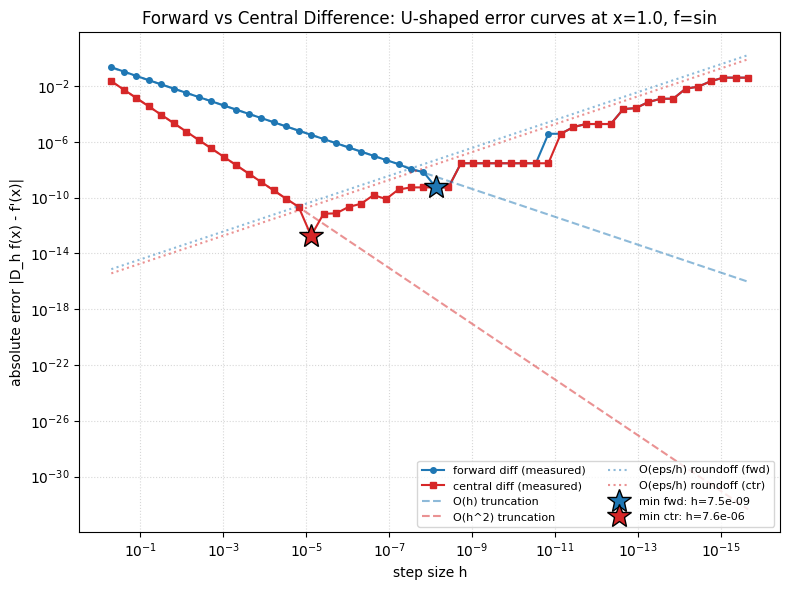

In [4]:
# 그래프
fig, ax = plt.subplots(figsize=(8, 6))

ax.loglog(h_arr, err_fwd, "o-", color="#1f77b4", ms=4, label="forward diff (measured)")
ax.loglog(h_arr, err_ctr, "s-", color="#d62728", ms=4, label="central diff (measured)")

# 절단오차 점근선
h_ref = h_arr
trunc_fwd = 0.5 * f2 * h_ref
trunc_ctr = (f3 / 6.0) * h_ref**2
round_fwd = 2.0 * eps * f0 / h_ref
round_ctr = eps * f0 / h_ref

ax.loglog(h_ref, trunc_fwd, "--", color="#1f77b4", alpha=0.5, label="O(h) truncation")
ax.loglog(h_ref, trunc_ctr, "--", color="#d62728", alpha=0.5, label="O(h^2) truncation")
ax.loglog(h_ref, round_fwd, ":",  color="#1f77b4", alpha=0.5, label="O(eps/h) roundoff (fwd)")
ax.loglog(h_ref, round_ctr, ":",  color="#d62728", alpha=0.5, label="O(eps/h) roundoff (ctr)")

# 측정 최소점
ax.plot(hmin_fwd, emin_fwd, "*", color="#1f77b4", ms=18, mec="black", label=f"min fwd: h={hmin_fwd:.1e}")
ax.plot(hmin_ctr, emin_ctr, "*", color="#d62728", ms=18, mec="black", label=f"min ctr: h={hmin_ctr:.1e}")

ax.set_xlabel("step size h")
ax.set_ylabel("absolute error |D_h f(x) - f'(x)|")
ax.set_title("Forward vs Central Difference: U-shaped error curves at x=1.0, f=sin")
ax.grid(True, which="both", ls=":", alpha=0.5)
ax.legend(loc="lower right", fontsize=8, ncol=2)
ax.invert_xaxis()
plt.tight_layout()
plt.show()


## 4. 결과 해석

1. **큰 $h$ 영역** — 두 곡선은 절단오차에 지배되며 기울기가 다르다.
   - 전진차분: 기울기 $-1$ (i.e. $\propto h^1$)
   - 중심차분: 기울기 $-2$ (i.e. $\propto h^2$)
   같은 $h$ 에서 *중심차분의 절단오차가 한 자릿수 이상 작다*.
2. **작은 $h$ 영역** — 두 곡선 모두 round-off 가 지배해 $\propto 1/h$. 두 기울기가 같다.
3. **최적 위치** — U자의 바닥은
   - 전진차분: $h^* \approx \sqrt{\varepsilon} \approx 1.5 \times 10^{-8}$,
     최소 오차 $\approx 10^{-8}$.
   - 중심차분: $h^* \approx \varepsilon^{1/3} \approx 6 \times 10^{-6}$,
     최소 오차 $\approx 10^{-11}$.
   *측정된 값* 과 이론 예측이 한 자릿수 이내로 일치.
4. **세 자릿수 이득** — 같은 함수, 같은 $x$, 같은 부동소수점 정밀도에서 중심차분 하나로
   *3 자릿수* 더 정확한 미분값을 얻는다. 이는 *공짜 점심* 처럼 보이지만, 사실은
   $f$ 의 *두 점을 더 잘 활용* (대칭성으로 $h$ 의 짝수 차수만 남김) 한 결과다.

> **결론**: 중심차분은 $O(h^2)$ 절단오차 덕에 더 큰 $h$ 에서 더 작은 오차를 낸다 —
> $h^*$ 는 $\sqrt{\varepsilon} \to \varepsilon^{1/3}$, 최소 오차는 $\varepsilon^{1/2} \to \varepsilon^{2/3}$.

### 다음 문제로의 연결
$O(h^2)$ 가 *공짜* 라면, *더 높은 차수* 도 가능할까? 다음 문제에서는 **Richardson 외삽**
으로 중심차분의 $h$ 와 $h/2$ 두 값으로부터 $O(h^4)$, 또 $h/4$ 까지 결합해 $O(h^6)$ 까지
*체계적으로* 차수를 올린다.